# Brownian Bridge

A **Brownian bridge** is a Brownian motion **conditioned** to return to a specific point 
at a specific time. It's the stochastic process equivalent of drawing a curve through 
two fixed points with random wiggles in between.

## The Standard Brownian Bridge

A standard Brownian bridge $B(t)$ on $[0, T]$ satisfies:

1. **$B(0) = 0$**
2. **$B(T) = 0$**
3. **Gaussian increments** with the same local behavior as Brownian motion

## Construction from Standard BM

If $W(t)$ is standard Brownian motion, then:

$$\boxed{B(t) = W(t) - \frac{t}{T} W(T)}$$

This subtracts the "drift" that would take $W(t)$ to $W(T)$ at time $T$, forcing the path 
to return to zero.

## General Brownian Bridge

From $a$ at $t=0$ to $b$ at $t=T$:

$$\boxed{B(t) = a + \frac{b-a}{T} t + W(t) - \frac{t}{T} W(T)}$$

The first two terms give the **linear trend**; the last two give the **random fluctuations**.


## Statistical Properties of the Standard Bridge

| Property | Formula |
|----------|---------|
| **Mean** | $\mathbb{E}[B(t)] = 0$ |
| **Variance** | $\text{Var}(B(t)) = t\left(1 - \frac{t}{T}\right)$ |
| **Standard deviation** | $\sigma_{B(t)} = \sqrt{t(1-t/T)}$ |
| **Covariance** | $\text{Cov}(B(s), B(t)) = \min(s,t) - \frac{st}{T}$ |
| **Distribution** | $B(t) \sim \mathcal{N}\left(0, t(1-t/T)\right)$ |

## Key Observations

1. **Variance is zero at endpoints**: $\text{Var}(B(0)) = \text{Var}(B(T)) = 0$
   - The path is **pinned** at both ends — no uncertainty there.

2. **Maximum variance at midpoint**: $\text{Var}(B(T/2)) = T/4$
   - The path has the most "freedom" in the middle.

3. **Symmetry**: The variance envelope is a **parabola** opening downward.

4. **Time reversal**: $B(t)$ and $B(T-t)$ have the **same distribution**.
5. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def simulate_brownian_bridge(T=1.0, N=1000, a=0.0, b=0.0, n_paths=5, seed=None):
    """
    Simulate Brownian bridge from a at t=0 to b at t=T.
    
    Construction: B(t) = a + (b-a)*t/T + W(t) - (t/T)*W(T)
    
    Parameters:
    -----------
    T : float
        Final time
    N : int
        Number of time steps
    a : float
        Starting value B(0)
    b : float
        Ending value B(T)
    n_paths : int
        Number of independent paths
    seed : int or None
        Random seed for reproducibility
        
    Returns:
    --------
    t : ndarray, shape (N+1,)
        Time grid
    B : ndarray, shape (n_paths, N+1)
        Brownian bridge paths
    """
    if seed is not None:
        np.random.seed(seed)
    
    dt = T / N
    t = np.linspace(0, T, N + 1)
    
    # Generate standard Brownian motion
    dW = np.random.normal(0, np.sqrt(dt), size=(n_paths, N))
    W = np.zeros((n_paths, N + 1))
    W[:, 1:] = np.cumsum(dW, axis=1)
    
    # Brownian bridge formula
    # B(t) = a + (b-a)*t/T + W(t) - (t/T)*W(T)
    B = a + (b - a) * (t / T) + W - np.outer(W[:, -1], t / T)
    
    return t, B

# Test it
t, B = simulate_brownian_bridge(T=1.0, N=1000, a=0, b=0, n_paths=5, seed=42)
print(f"Shape: {B.shape}")
print(f"B(0) = {B[:, 0]}")   # Should all be 0
print(f"B(1) = {B[:, -1]}")  # Should all be 0 (within floating point)


Shape: (5, 1001)
B(0) = [0. 0. 0. 0. 0.]
B(1) = [0. 0. 0. 0. 0.]


## Derivation of the Bridge Formula

We want $B(t) = W(t)$ for $t \in [0, T)$, but with $B(T) = 0$.

### The Conditioning Trick

Consider the conditional distribution of $W(t)$ given $W(T) = 0$:

$$W(t) \mid W(T) = 0 \sim \mathcal{N}\left(0, t\left(1 - \frac{t}{T}\right)\right)$$

This is exactly the bridge! The formula:

$$B(t) = W(t) - \frac{t}{T} W(T)$$

is the **orthogonal projection** of $W(t)$ onto the subspace of paths that end at 0.

### Intuition

- $W(t)$ is the unconstrained path
- $\frac{t}{T} W(T)$ is the "expected position" at time $t$ if $W$ were a straight line from 0 to $W(T)$
- Subtracting this removes the drift component, leaving only the fluctuations that sum to zero

### Alternative: SDE Formulation

The Brownian bridge also satisfies:

$$dB(t) = -\frac{B(t)}{T-t} \, dt + dW(t), \quad B(0) = 0$$

The drift term $-\frac{B(t)}{T-t}$ is a **mean-reverting force** that pulls the path 
back to zero with increasing strength as $t \to T$. As $t \to T$, the drift explodes 
to ensure $B(T) = 0$.


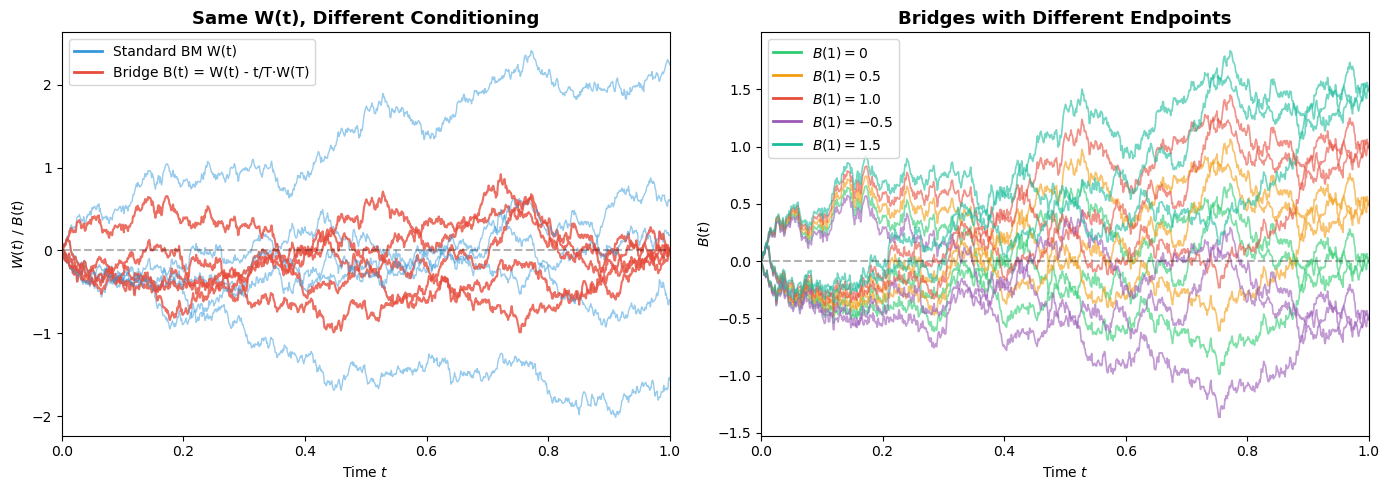

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Standard BM vs Bridge ---
ax = axes[0]
np.random.seed(42)
T, N = 1.0, 1000
dt = T / N
t = np.linspace(0, T, N + 1)

dW = np.random.normal(0, np.sqrt(dt), size=(5, N))
W = np.zeros((5, N + 1))
W[:, 1:] = np.cumsum(dW, axis=1)

# Bridge from same W
B = W - np.outer(W[:, -1], t / T)

for i in range(5):
    ax.plot(t, W[i], color='#3498db', alpha=0.5, linewidth=1)
    ax.plot(t, B[i], color='#e74c3c', alpha=0.8, linewidth=1.5)

ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.plot([], [], color='#3498db', linewidth=2, label='Standard BM W(t)')
ax.plot([], [], color='#e74c3c', linewidth=2, label='Bridge B(t) = W(t) - t/T·W(T)')
ax.set_title('Same W(t), Different Conditioning', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$')
ax.set_ylabel('$W(t)$ / $B(t)$')
ax.legend(fontsize=10)
ax.set_xlim(0, 1)

# --- Right: Bridges with different endpoints ---
ax = axes[1]
endpoints = [0, 0.5, 1.0, -0.5, 1.5]
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c']

for b, color in zip(endpoints, colors):
    t, B = simulate_brownian_bridge(T=1.0, N=1000, a=0, b=b, n_paths=3, seed=42)
    for i in range(3):
        ax.plot(t, B[i], color=color, alpha=0.6, linewidth=1.2)
    ax.plot([], [], color=color, linewidth=2, label=f'$B(1) = {b}$')

ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.set_title('Bridges with Different Endpoints', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$')
ax.set_ylabel('$B(t)$')
ax.legend(fontsize=10)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()


## The Variance Envelope

For a standard bridge ($a=b=0$, $T=1$):

$$\text{Var}(B(t)) = t(1-t)$$

This is a **parabola** that:
- Equals 0 at $t=0$ and $t=1$
- Peaks at $t = 0.5$ with value $\text{Var}(B(0.5)) = 0.25$
- Standard deviation: $\sigma_{B(t)} = \sqrt{t(1-t)}$

For a general bridge from $a$ to $b$:

$$\text{Var}(B(t)) = \sigma^2 t\left(1 - \frac{t}{T}\right)$$

The mean path is always the **straight line** from $a$ to $b$:

$$\mathbb{E}[B(t)] = a + \frac{b-a}{T} t$$

> **Visual metaphor:** Imagine stretching a rubber band between two nails. 
> The rubber band is the mean path. The Brownian bridge is like flicking the rubber band 
> — it wiggles most in the middle and is pinned at both ends.


<ipython-input-3-59a8c94a8deb>:47: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


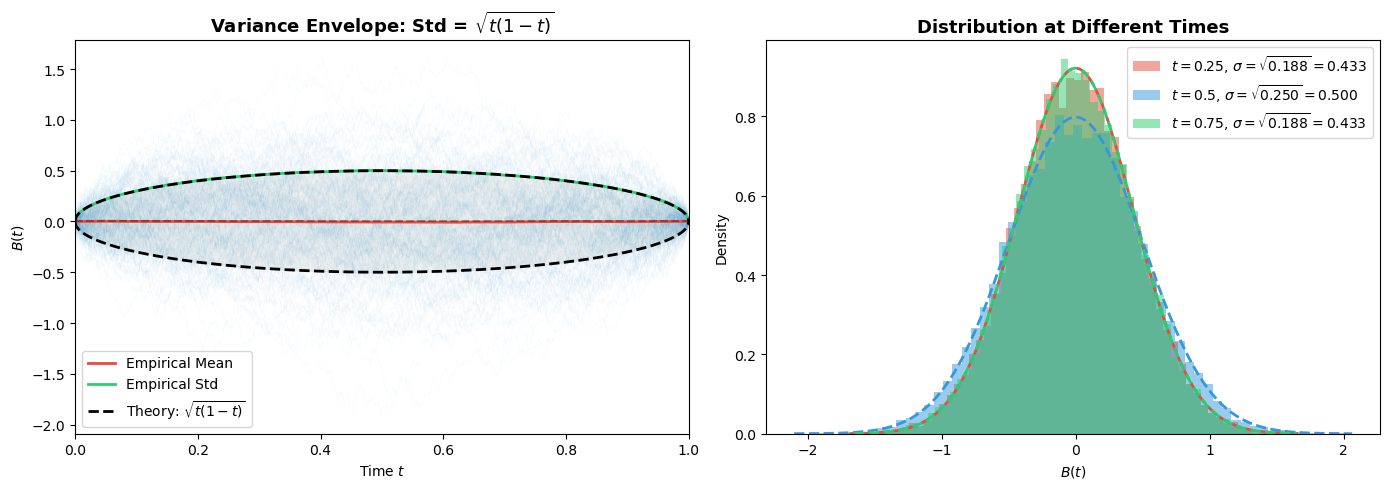

Variance at t=0.5: 0.2516 (theory: 0.25)
Std at t=0.5: 0.5016 (theory: 0.5)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Variance envelope with many paths ---
ax = axes[0]
np.random.seed(77)
t, B_large = simulate_brownian_bridge(T=1.0, N=1000, a=0, b=0, n_paths=20000, seed=77)

emp_mean = np.mean(B_large, axis=0)
emp_std = np.std(B_large, axis=0)
theory_std = np.sqrt(t * (1 - t))

for i in range(min(200, B_large.shape[0])):
    ax.plot(t, B_large[i], color='#3498db', alpha=0.03, linewidth=0.5)

ax.plot(t, emp_mean, color='#e74c3c', linewidth=2, label='Empirical Mean')
ax.plot(t, emp_std, color='#2ecc71', linewidth=2, label='Empirical Std')
ax.plot(t, theory_std, 'k--', linewidth=2, label='Theory: $\\sqrt{t(1-t)}$')
ax.plot(t, -theory_std, 'k--', linewidth=2)
ax.fill_between(t, theory_std, -theory_std, alpha=0.1, color='gray')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.set_title('Variance Envelope: Std = $\\sqrt{t(1-t)}$', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$')
ax.set_ylabel('$B(t)$')
ax.legend(fontsize=10)
ax.set_xlim(0, 1)

# --- Right: Distribution at different times ---
ax = axes[1]
time_points = [0.25, 0.5, 0.75]
colors_tp = ['#e74c3c', '#3498db', '#2ecc71']

for tp, color in zip(time_points, colors_tp):
    idx = int(tp * 1000)
    values = B_large[:, idx]
    ax.hist(values, bins=60, density=True, alpha=0.5, color=color, 
            label=f'$t={tp}$, $\\sigma=\\sqrt{{{tp*(1-tp):.3f}}}={np.sqrt(tp*(1-tp)):.3f}$')
    
    x_range = np.linspace(values.min(), values.max(), 200)
    theory_pdf = stats.norm.pdf(x_range, 0, np.sqrt(tp * (1 - tp)))
    ax.plot(x_range, theory_pdf, color=color, linewidth=2, linestyle='--')

ax.set_title('Distribution at Different Times', fontsize=13, fontweight='bold')
ax.set_xlabel('$B(t)$')
ax.set_ylabel('Density')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"Variance at t=0.5: {np.var(B_large[:, 500]):.4f} (theory: 0.25)")
print(f"Std at t=0.5: {np.std(B_large[:, 500]):.4f} (theory: 0.5)")


## Application 1: Interpolating Between Known Points

Suppose you know the price of a stock at $t=0$ and $t=T$, but not in between. 
A Brownian bridge gives the **most likely** path consistent with those endpoints.

### Why Not Just a Straight Line?

A straight line assumes zero volatility. The Brownian bridge adds realistic 
random fluctuations while respecting the known endpoints.

### Formula

Given $S(0) = S_0$ and $S(T) = S_T$, the bridge interpolation is:

$$S(t) = S_0 + \frac{S_T - S_0}{T} t + \sigma \left[W(t) - \frac{t}{T} W(T)\right]$$

The first two terms give the linear trend; the last term adds Brownian noise 
with the correct variance structure.


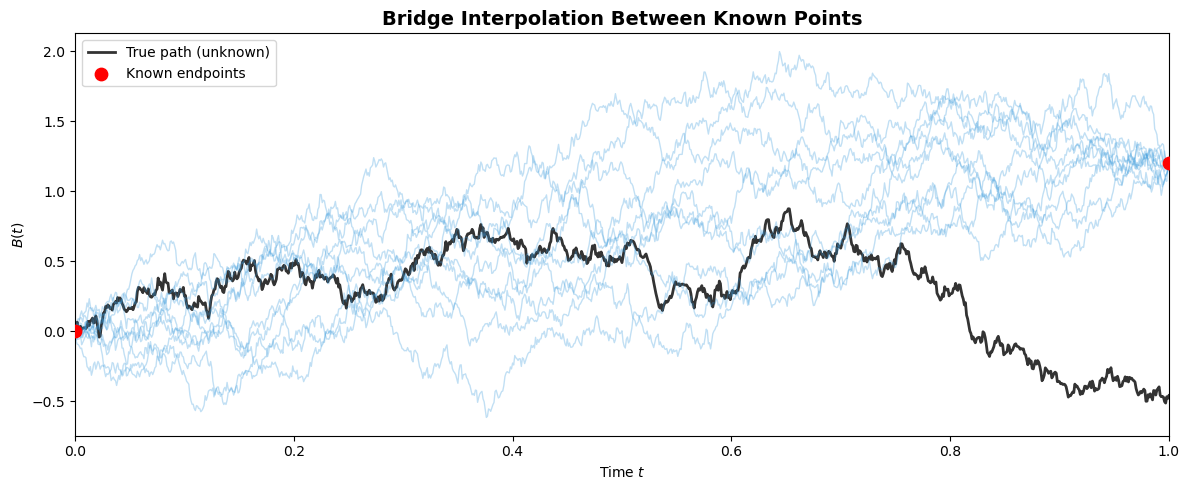

In [4]:
np.random.seed(10)
T, N = 1.0, 1000
dt = T / N
t = np.linspace(0, T, N + 1)

# Known endpoints
W0, WT = 0.0, 1.2

# Generate a "true" path (unknown in practice)
dW = np.random.normal(0, np.sqrt(dt), N)
W_true = np.concatenate([[W0], np.cumsum(dW)])

# Bridge interpolations (only using endpoints)
dW_bridge = np.random.normal(0, np.sqrt(dt), size=(10, N))
W_bridge = np.zeros((10, N + 1))
W_bridge[:, 1:] = np.cumsum(dW_bridge, axis=1)
B = W0 + (WT - W0) * (t / T) + W_bridge - np.outer(W_bridge[:, -1], t / T)

plt.figure(figsize=(12, 5))
plt.plot(t, W_true, color='black', linewidth=2, alpha=0.8, label='True path (unknown)')
for i in range(10):
    plt.plot(t, B[i], color='#3498db', alpha=0.3, linewidth=1)
plt.scatter([0, 1], [W0, WT], color='red', s=80, zorder=5, label='Known endpoints')
plt.title('Bridge Interpolation Between Known Points', fontsize=14, fontweight='bold')
plt.xlabel('Time $t$')
plt.ylabel('$B(t)$')
plt.legend(fontsize=10)
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


## Application 2: Barrier Crossing Probabilities

For a standard Brownian bridge on $[0, 1]$, the probability that the maximum 
exceeds level $c > 0$ is:

$$\boxed{P\left(\max_{0 \leq t \leq 1} B(t) > c\right) = e^{-2c^2}}$$

### Derivation Sketch

This comes from the **reflection principle** applied to conditioned Brownian motion. 
The bridge is a Brownian motion conditioned on $W(1) = 0$, so we use Bayes' rule 
and the known hitting probabilities of Brownian motion.

### The Maximum Distribution

The PDF of $M = \max_{0 \leq t \leq 1} B(t)$ is:

$$f_M(m) = 4m \, e^{-2m^2}, \quad m > 0$$

This is a **Rayleigh-like** distribution.


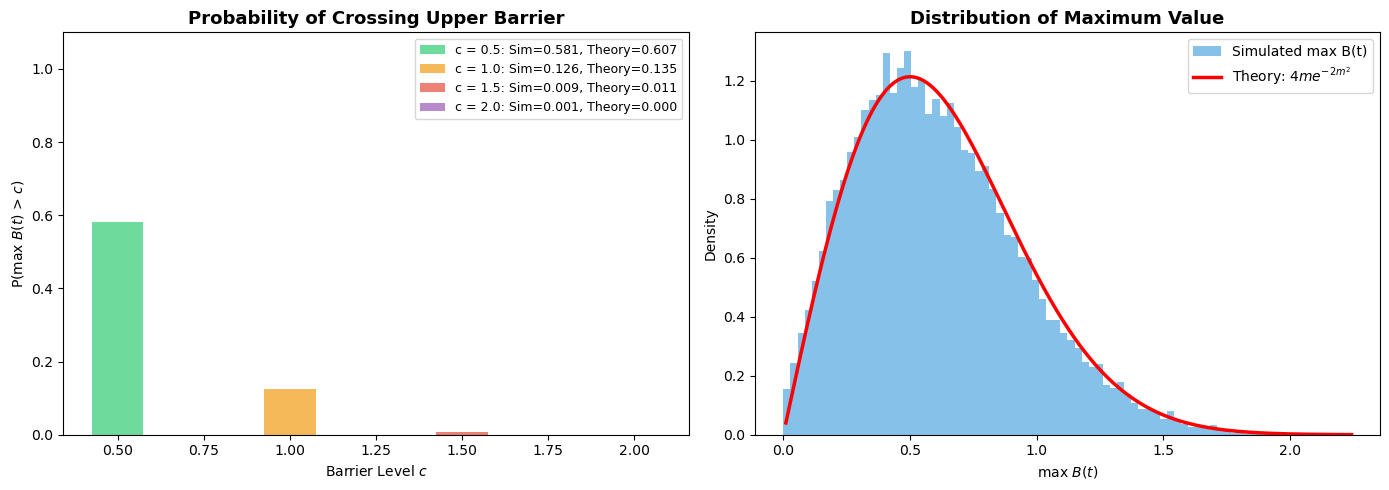

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Hitting probabilities ---
ax = axes[0]
np.random.seed(30)
t, B_large = simulate_brownian_bridge(T=1.0, N=1000, a=0, b=0, n_paths=5000, seed=30)

barriers = [0.5, 1.0, 1.5, 2.0]
colors_bar = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']

for barrier, color in zip(barriers, colors_bar):
    hit_prob = np.mean(np.any(B_large > barrier, axis=1))
    theory_prob = np.exp(-2 * barrier**2)
    ax.bar(barrier, hit_prob, width=0.15, color=color, alpha=0.7, 
           label=f'c = {barrier}: Sim={hit_prob:.3f}, Theory={theory_prob:.3f}')

ax.set_title('Probability of Crossing Upper Barrier', fontsize=13, fontweight='bold')
ax.set_xlabel('Barrier Level $c$')
ax.set_ylabel('P(max $B(t)$ > $c$)')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.1)

# --- Right: Maximum distribution ---
ax = axes[1]
np.random.seed(40)
t, B_max = simulate_brownian_bridge(T=1.0, N=1000, a=0, b=0, n_paths=20000, seed=40)
max_values = np.max(B_max, axis=1)

ax.hist(max_values, bins=80, density=True, alpha=0.6, color='#3498db', label='Simulated max B(t)')
x_range = np.linspace(0.01, max(max_values), 300)
theory_pdf_max = 4 * x_range * np.exp(-2 * x_range**2)
ax.plot(x_range, theory_pdf_max, 'r-', linewidth=2.5, label='Theory: $4m e^{-2m^2}$')
ax.set_title('Distribution of Maximum Value', fontsize=13, fontweight='bold')
ax.set_xlabel('max $B(t)$')
ax.set_ylabel('Density')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


## Application 3: The Kolmogorov-Smirnov Test

The Brownian bridge appears in one of the most famous results in statistics.

### The Empirical CDF

For i.i.d. samples $X_1, \ldots, X_n$ with CDF $F(x)$, the empirical CDF is:

$$F_n(x) = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}_{X_i \leq x}$$

### The KS Statistic

$$D_n = \sup_x |F_n(x) - F(x)|$$

### The Amazing Result (Kolmogorov, 1933)

As $n \to \infty$:

$$\sqrt{n} \cdot D_n \xrightarrow{d} \sup_{0 \leq t \leq 1} |B(t)|$$

where $B(t)$ is a standard Brownian bridge!

### Why?

By the **probability integral transform**, $F(X_i) \sim \text{Uniform}(0,1)$. 
The empirical CDF of uniform variables converges to a Brownian bridge when properly scaled.

### Practical Use

This gives us the **critical values** for the KS test without simulation:

$$P(\sqrt{n} D_n > 1.358) \approx 0.05 \quad \text{(5% significance level)}$$


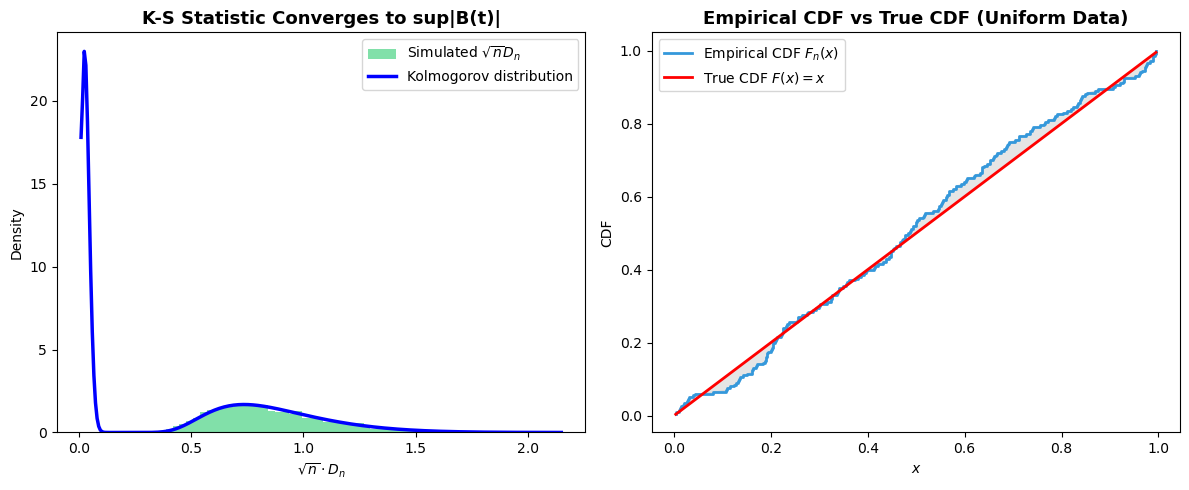

Mean of sqrt(n)*D_n: 0.852
Critical value (5%): 0.039


In [6]:
np.random.seed(50)
n_samples = 1000
n_sims = 5000
ks_stats = []

for _ in range(n_sims):
    data = np.random.normal(0, 1, n_samples)
    sorted_data = np.sort(data)
    empirical = np.arange(1, n_samples + 1) / n_samples
    theoretical = stats.norm.cdf(sorted_data)
    D_n = np.max(np.abs(empirical - theoretical))
    ks_stats.append(np.sqrt(n_samples) * D_n)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(ks_stats, bins=60, density=True, alpha=0.6, color='#2ecc71', 
         label=r'Simulated $\sqrt{n} D_n$')

# Kolmogorov distribution CDF
from scipy.special import erfc
x_ks = np.linspace(0.01, max(ks_stats), 300)
ks_cdf = lambda x: 1 - 2 * np.sum([(-1)**(k-1) * np.exp(-2 * k**2 * x**2) 
                                    for k in range(1, 20)], axis=0)
ks_pdf_approx = np.gradient(ks_cdf(x_ks), x_ks)
plt.plot(x_ks, ks_pdf_approx, 'b-', linewidth=2.5, label='Kolmogorov distribution')

plt.title('K-S Statistic Converges to sup|B(t)|', fontsize=13, fontweight='bold')
plt.xlabel(r'$\sqrt{n} \cdot D_n$')
plt.ylabel('Density')
plt.legend(fontsize=10)

plt.subplot(1, 2, 2)
# Compare empirical CDF of uniform data to uniform CDF
np.random.seed(60)
n = 200
uniform_data = np.random.uniform(0, 1, n)
sorted_u = np.sort(uniform_data)
empirical_u = np.arange(1, n + 1) / n
theoretical_u = sorted_u  # F(x) = x for uniform

# Brownian bridge representation
bridge_vals = np.sqrt(n) * (empirical_u - theoretical_u)

plt.step(sorted_u, empirical_u, where='post', color='#3498db', linewidth=2, 
         label='Empirical CDF $F_n(x)$')
plt.plot(sorted_u, theoretical_u, color='red', linewidth=2, label='True CDF $F(x) = x$')
plt.fill_between(sorted_u, empirical_u, theoretical_u, alpha=0.2, color='gray')
plt.title('Empirical CDF vs True CDF (Uniform Data)', fontsize=13, fontweight='bold')
plt.xlabel('$x$')
plt.ylabel('CDF')
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean of sqrt(n)*D_n: {np.mean(ks_stats):.3f}")
print(f"Critical value (5%): {stats.ksone.ppf(0.95, n_samples):.3f}")


## General Brownian Bridge (Non-Zero Endpoints)

For a bridge from $a$ at $t=0$ to $b$ at $t=T$:

$$B(t) = a + \frac{b-a}{T} t + \sigma \left[W(t) - \frac{t}{T} W(T)\right]$$

| Property | Formula |
|----------|---------|
| **Mean** | $\mathbb{E}[B(t)] = a + \frac{b-a}{T} t$ |
| **Variance** | $\text{Var}(B(t)) = \sigma^2 t\left(1 - \frac{t}{T}\right)$ |
| **Distribution** | $B(t) \sim \mathcal{N}\left(a + \frac{b-a}{T}t, \sigma^2 t(1-t/T)\right)$ |

## Time Reversal Property

$$B(t) \stackrel{d}{=} B(T-t)$$

The bridge looks the same forwards and backwards. This is obvious from the construction: 
pinning at both ends creates symmetry.

## SDE Formulation

$$dB(t) = \frac{b - B(t)}{T-t} \, dt + \sigma \, dW(t)$$

The drift $\frac{b - B(t)}{T-t}$ is a **pulling force** toward $b$ that becomes 
infinitely strong as $t \to T$, guaranteeing $B(T) = b$.


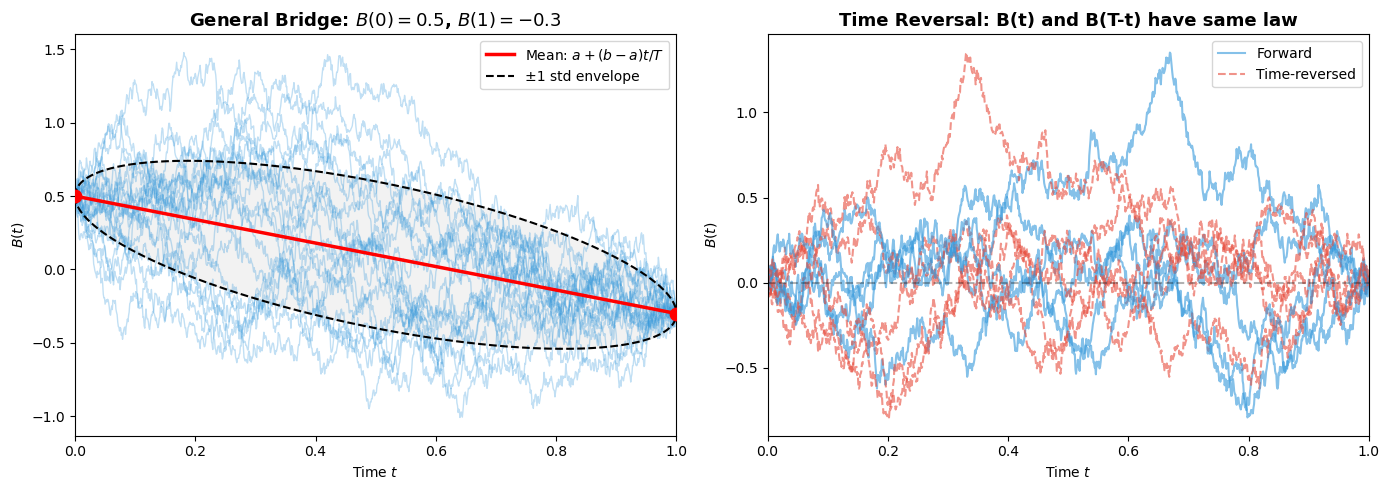

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: General bridge with drift ---
ax = axes[0]
np.random.seed(60)
a, b = 0.5, -0.3
t, B_gen = simulate_brownian_bridge(T=1.0, N=1000, a=a, b=b, n_paths=20, seed=60)

for i in range(20):
    ax.plot(t, B_gen[i], color='#3498db', alpha=0.3, linewidth=1)

mean_path = a + (b - a) * t
ax.plot(t, mean_path, 'r-', linewidth=2.5, label=f'Mean: $a + (b-a)t/T$')
ax.plot(t, mean_path + np.sqrt(t * (1 - t)), 'k--', linewidth=1.5, label='±1 std envelope')
ax.plot(t, mean_path - np.sqrt(t * (1 - t)), 'k--', linewidth=1.5)
ax.fill_between(t, mean_path + np.sqrt(t * (1 - t)), mean_path - np.sqrt(t * (1 - t)), 
                alpha=0.1, color='gray')
ax.scatter([0, 1], [a, b], color='red', s=80, zorder=5)
ax.set_title(f'General Bridge: $B(0)={a}$, $B(1)={b}$', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$')
ax.set_ylabel('$B(t)$')
ax.legend(fontsize=10)
ax.set_xlim(0, 1)

# --- Right: Time reversal ---
ax = axes[1]
np.random.seed(20)
t, B = simulate_brownian_bridge(T=1.0, N=1000, a=0, b=0, n_paths=5, seed=20)

for i in range(5):
    ax.plot(t, B[i], color='#3498db', alpha=0.6, linewidth=1.5, label='Forward' if i == 0 else None)
    ax.plot(t, B[i, ::-1], color='#e74c3c', alpha=0.6, linewidth=1.5, linestyle='--', 
            label='Time-reversed' if i == 0 else None)

ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.set_title('Time Reversal: B(t) and B(T-t) have same law', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$')
ax.set_ylabel('$B(t)$')
ax.legend(fontsize=10)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()


## Complete Formula Reference

### Standard Brownian Bridge ($a=0, b=0, T=1$)
- **Construction**: $B(t) = W(t) - t \cdot W(1)$
- **Mean**: $\mathbb{E}[B(t)] = 0$
- **Variance**: $\text{Var}(B(t)) = t(1-t)$
- **Covariance**: $\text{Cov}(B(s), B(t)) = \min(s,t) - st$
- **Distribution**: $B(t) \sim \mathcal{N}(0, t(1-t))$

### General Brownian Bridge
- **Construction**: $B(t) = a + \frac{b-a}{T}t + W(t) - \frac{t}{T}W(T)$
- **Mean**: $\mathbb{E}[B(t)] = a + \frac{b-a}{T}t$
- **Variance**: $\text{Var}(B(t)) = \sigma^2 t(1-t/T)$

### Barrier Probabilities
- **Max exceeds $c$**: $P(\max B(t) > c) = e^{-2c^2}$
- **Max PDF**: $f_M(m) = 4m \, e^{-2m^2}$

### Kolmogorov-Smirnov
- **Asymptotic distribution**: $\sqrt{n} D_n \xrightarrow{d} \sup_{t} |B(t)|$
- 